In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
from scipy.stats import mannwhitneyu
from itertools import combinations

pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_parquet(r'/content/drive/MyDrive/Compartilhar/MODELO_3_TREINO_TESTE/df_churn_cliente.parquet')

In [ ]:
p_clusters = [c for c in df['rotulos40'].unique() if c.startswith('P_')]

p_clusters_sem_ruido = [c for c in p_clusters if c != 'P_Ruido']

df_filtrado = df[df['rotulos40'].isin(p_clusters_sem_ruido)].copy()

print("Análise apenas para os clusters Pagantes (excluindo P_Ruido).")
print("Clusters incluídos na análise:", p_clusters_sem_ruido)

Análise apenas para os clusters Pagantes (excluindo P_Ruido).
Clusters incluídos na análise: ['P_C5', 'P_C0', 'P_C2', 'P_C1', 'P_C3', 'P_C4']


In [ ]:
metrics = {
    'QTD_PRODUTOS_DISTINTOS': 'Qtd. Produtos Distintos',
    'VALOR_CONTRATOS_ATIVO': 'Valor Contratos Ativos (R$)',
    'VALOR_CONTRATOS_CANCELADO': 'Valor Contratos Cancelados (R$)',
    'SOMA_VL_CONTRATOS': 'Soma Total de Contratos (R$)',
    'MRR_12M': 'MRR Últimos 12 Meses (R$)',
    'VLR_CONTRATACOES_12M': 'Valor Novas Contratações (12M, R$)',
    'IDADE_ANOS': 'Idade do Cliente (Anos)',
    'CONTRATOS_ATIVO': 'Qtd. Contratos Ativos',
    'CONTRATOS_CANCELADO': 'Qtd. Contratos Cancelados',
    'EVENTDURATION_S': 'Tempo de Uso de Produtos TOTVS',
    'QTD_TICKETS': 'Qtd. Tickets Abertos'
}

numerical_cols = list(metrics.keys())

overall_avg_filtrado = df_filtrado[numerical_cols].mean()

cluster_avg_filtrado = df_filtrado.groupby('rotulos40')[numerical_cols].mean()

comparison_table_filtrada = cluster_avg_filtrado.T
comparison_table_filtrada['Média Geral (Pagantes)'] = overall_avg_filtrado

cols = ['Média Geral (Pagantes)'] + [col for col in comparison_table_filtrada.columns if col != 'Média Geral (Pagantes)']
comparison_table_filtrada = comparison_table_filtrada[cols]

comparison_table_filtrada = comparison_table_filtrada.rename(index=metrics)

print("\n--- Tabela Comparativa (Apenas Pagantes) ---")
pd.options.display.float_format = '{:,.2f}'.format
display(comparison_table_filtrada)


--- Tabela Comparativa (Apenas Pagantes) ---


rotulos40,Média Geral (Pagantes),P_C0,P_C1,P_C2,P_C3,P_C4,P_C5
Qtd. Produtos Distintos,9.39,19.92,11.40,15.27,9.82,12.59,9.12
Valor Contratos Ativos (R$),"11,583.45","39,973.62","14,452.14","19,262.21","15,557.61","5,335.84","11,145.65"
Valor Contratos Cancelados (R$),"3,481.02","13,918.51","2,587.73","3,007.81","2,135.56","1,164.20","3,416.90"
Soma Total de Contratos (R$),"15,119.57","57,266.42","17,042.91","23,177.89","17,693.18","6,687.81","14,568.18"
MRR Últimos 12 Meses (R$),442.08,764.90,570.03,692.80,255.32,171.57,437.23
"Valor Novas Contratações (12M, R$)","2,986.77","7,528.05","4,539.78","2,275.96","2,971.37",562.02,"2,879.39"
Idade do Cliente (Anos),7.16,10.72,3.70,6.82,6.88,7.40,7.18
Qtd. Contratos Ativos,7.65,17.33,10.44,12.31,11.02,8.08,7.40
Qtd. Contratos Cancelados,3.25,9.10,3.64,3.32,2.35,4.04,3.18
Tempo de Uso de Produtos TOTVS,474.35,"2,030.94",952.19,246.16,"1,169.57",193.66,400.17



--- Teste de Kruskal-Wallis ---
Variável: Qtd. Produtos Distintos
  Estatística H: 158.3545
  p-valor: 2.2192882891030893e-32
Variável: Valor Contratos Ativos (R$)
  Estatística H: 147.3533
  p-valor: 4.884297978155673e-30
Variável: Valor Contratos Cancelados (R$)
  Estatística H: 75.9857
  p-valor: 5.792350024012891e-15
Variável: Soma Total de Contratos (R$)
  Estatística H: 184.3789
  p-valor: 6.20967049228914e-38
Variável: MRR Últimos 12 Meses (R$)
  Estatística H: 92.0147
  p-valor: 2.5348134689094665e-18
Variável: Valor Novas Contratações (12M, R$)
  Estatística H: 43.3635
  p-valor: 3.118385602932863e-08
Variável: Idade do Cliente (Anos)
  Estatística H: 120.4845
  p-valor: 2.478039459964493e-24
Variável: Qtd. Contratos Ativos
  Estatística H: 109.2747
  p-valor: 5.831180298650544e-22
Variável: Qtd. Contratos Cancelados
  Estatística H: 71.8022
  p-valor: 4.319070343020747e-14
Variável: Tempo de Uso de Produtos TOTVS
  Estatística H: 45.0987
  p-valor: 1.3853453337076057e-08
Var

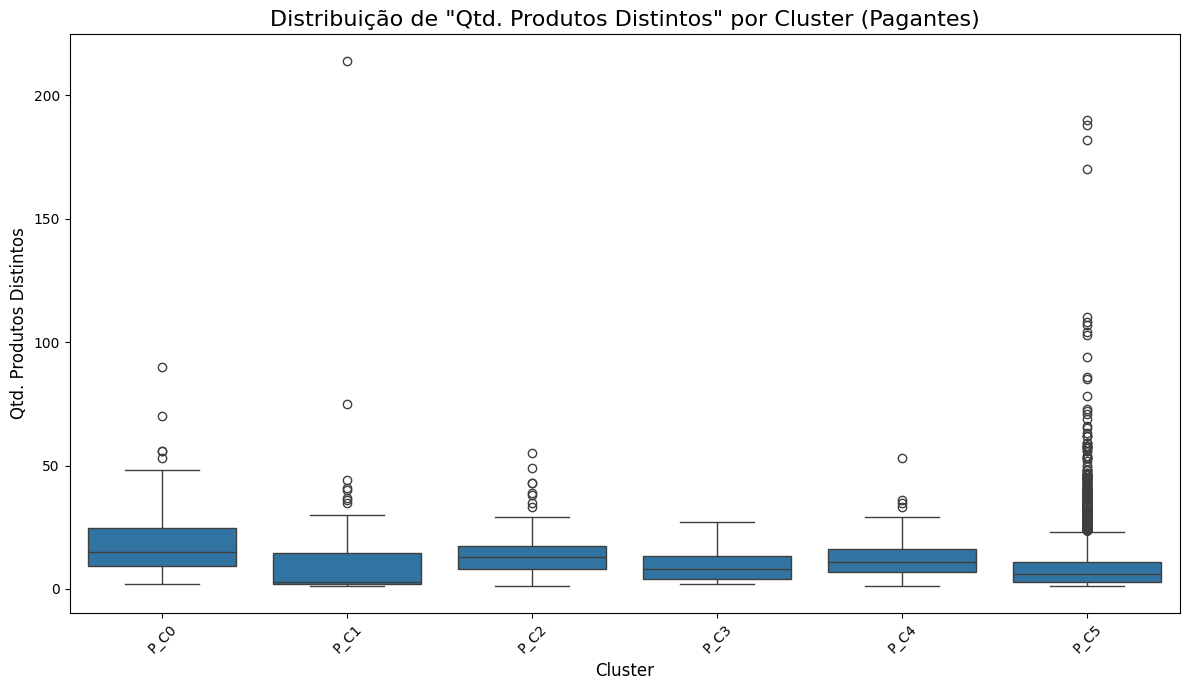

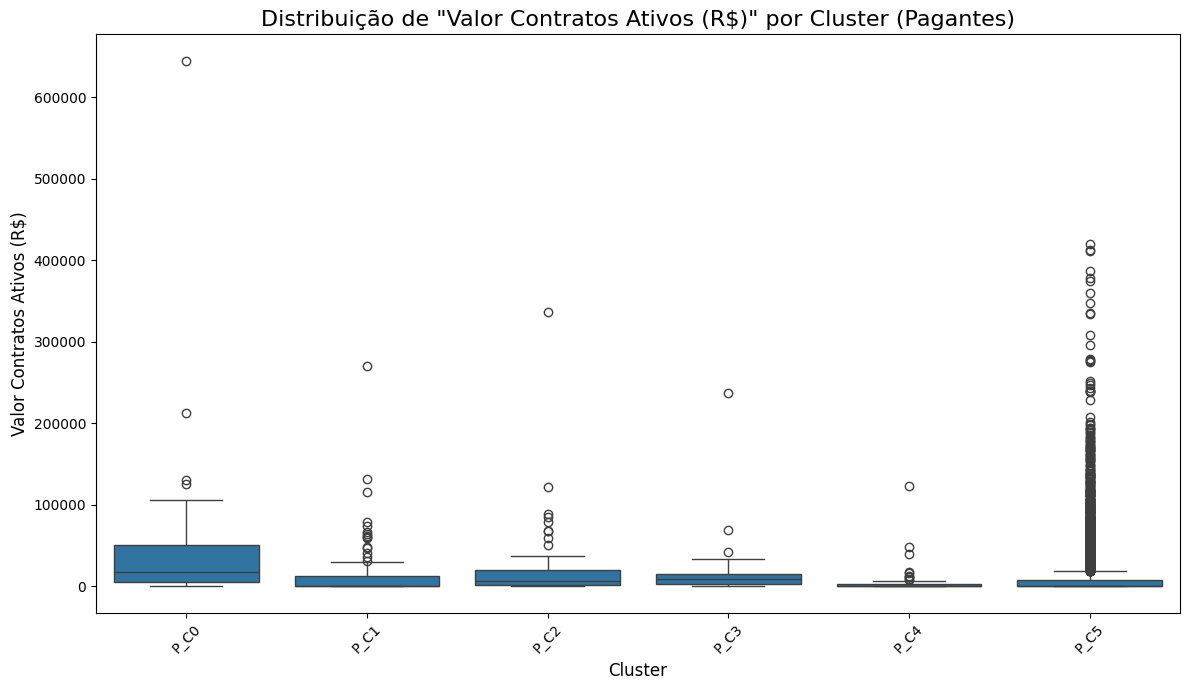

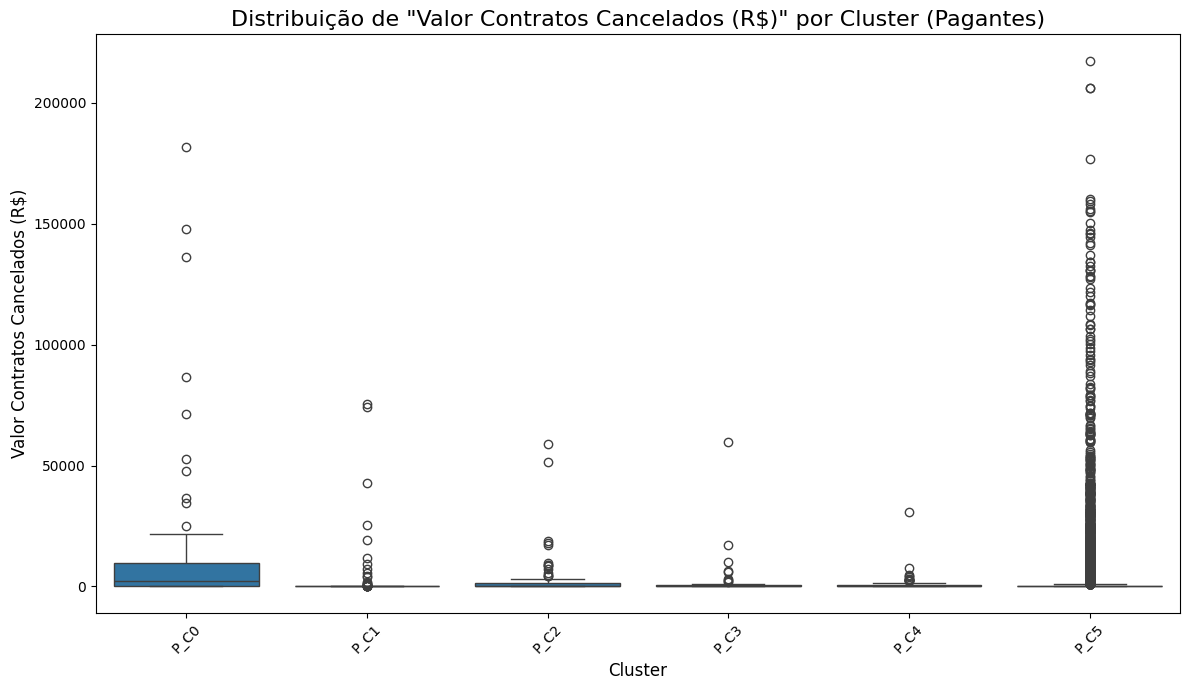

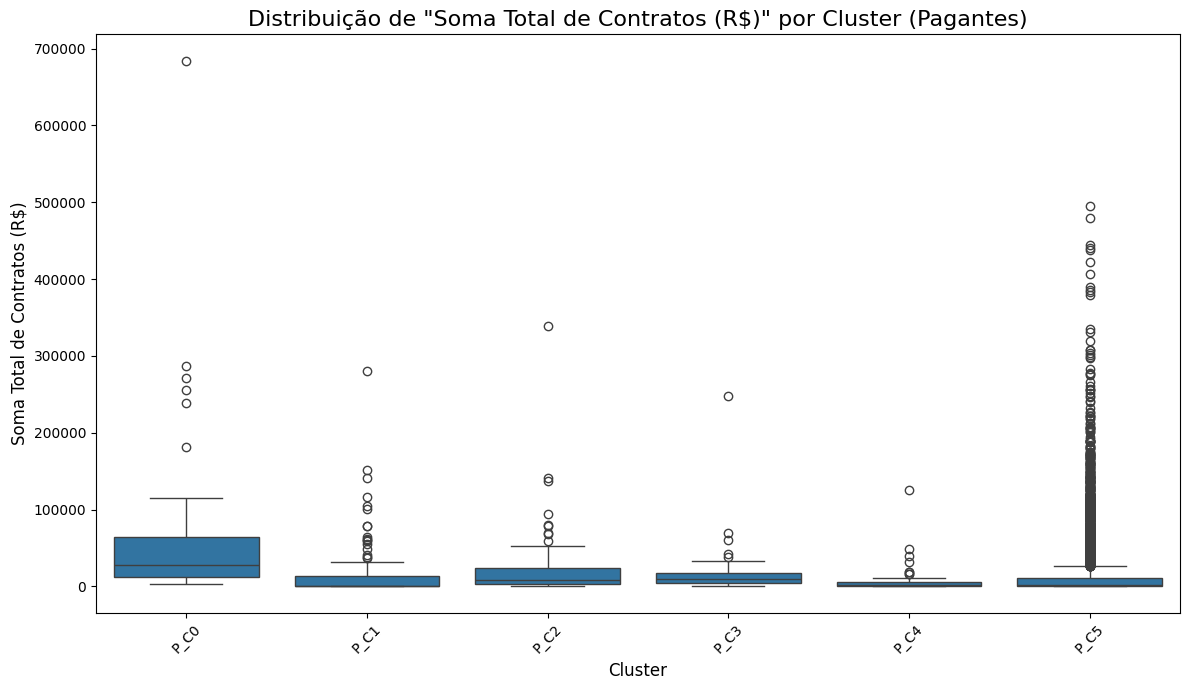

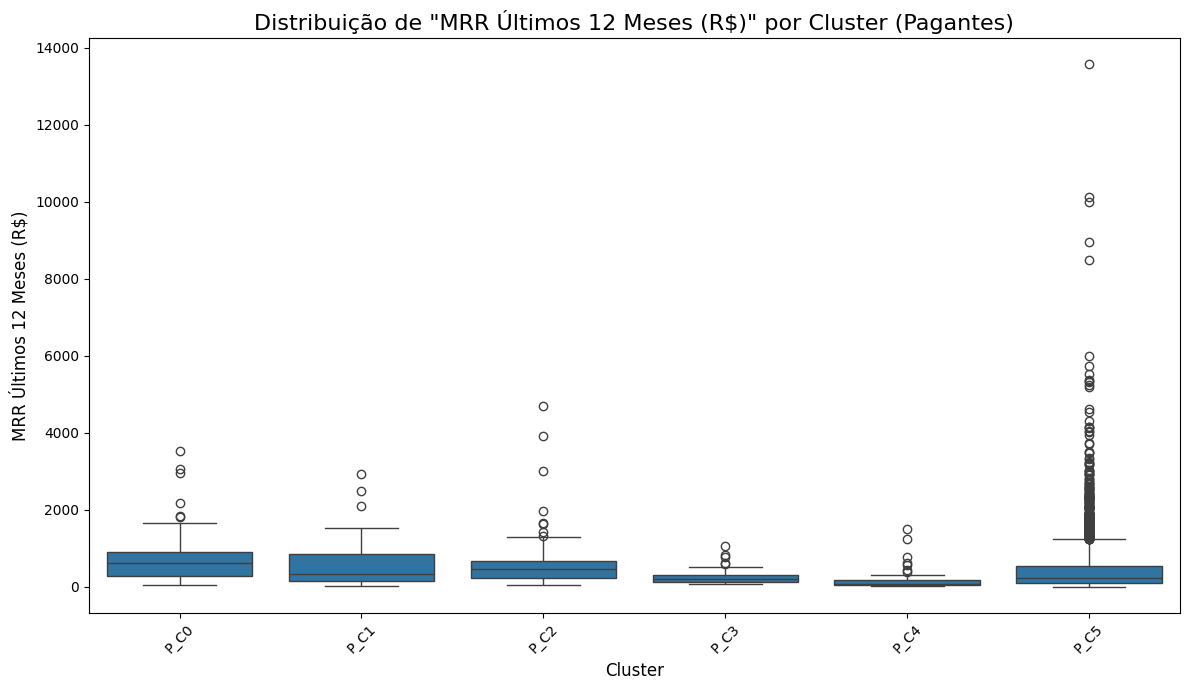

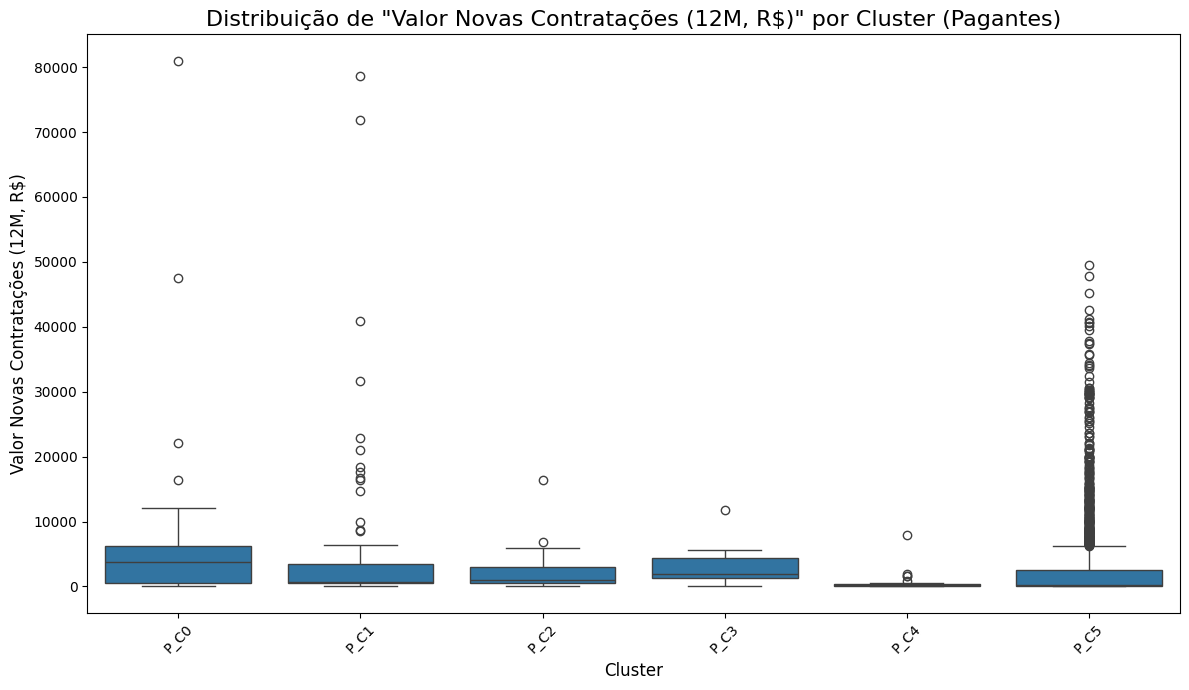

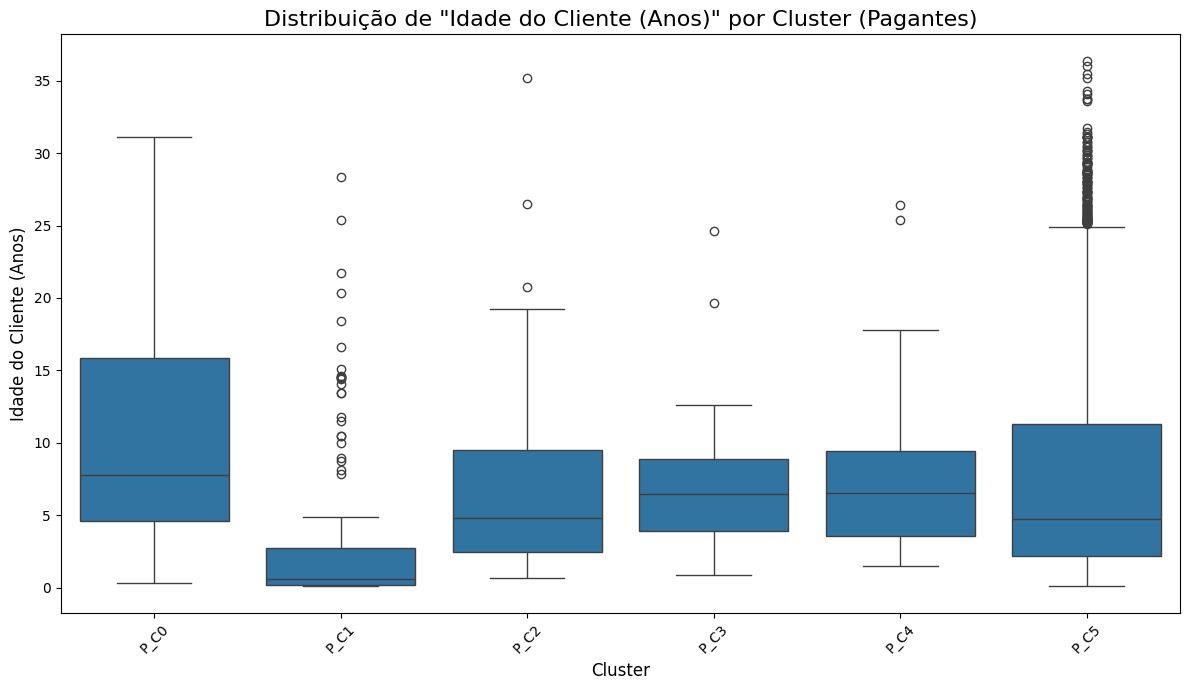

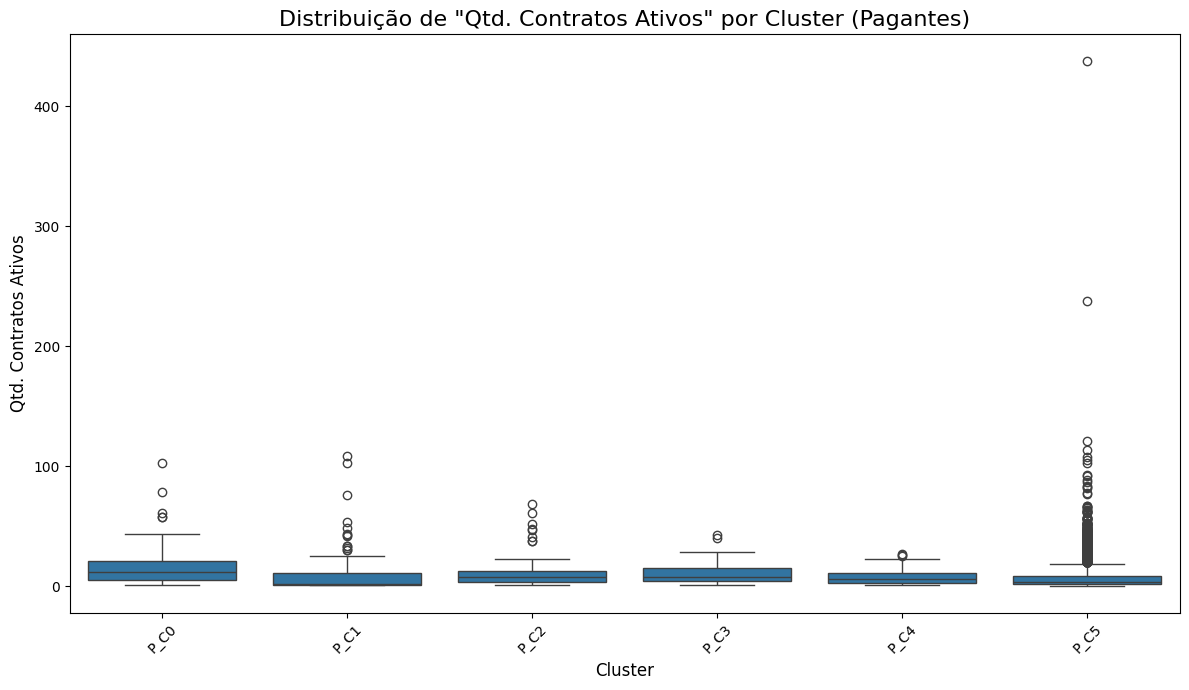

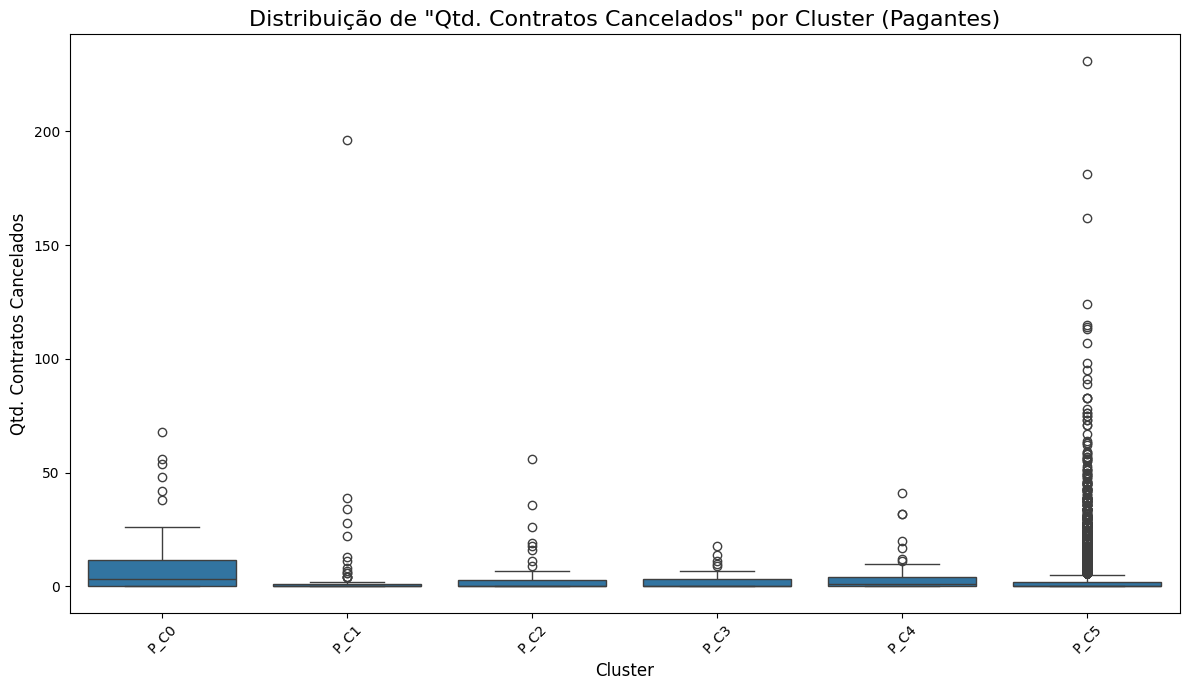

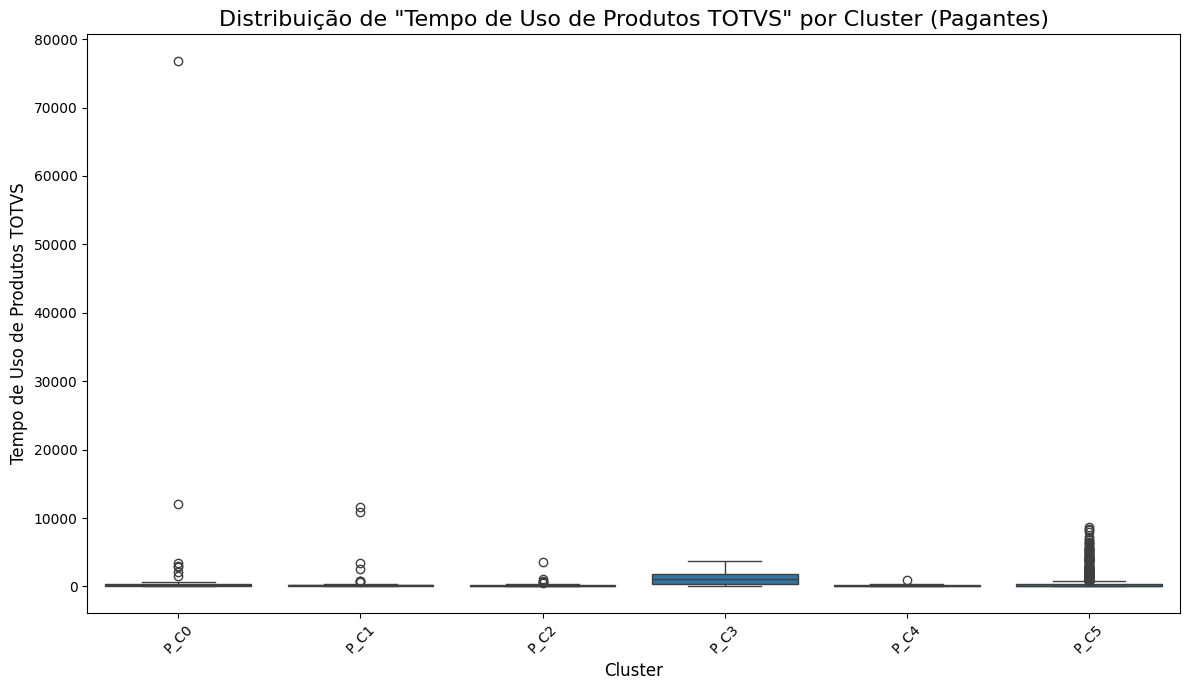

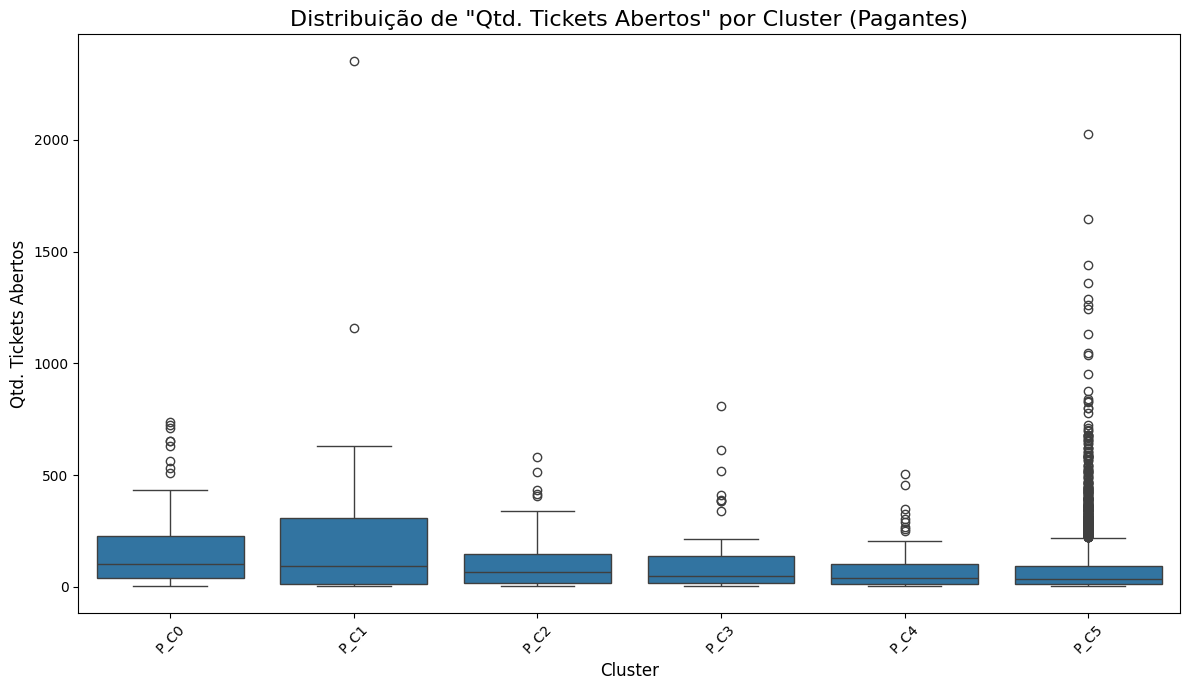

In [ ]:
print("\n--- Teste de Kruskal-Wallis ---")
results_filtrado = {}
for col in numerical_cols:
    samples = [df_filtrado[col][df_filtrado['rotulos40'] == cluster].dropna() for cluster in p_clusters_sem_ruido]

    if len(samples) > 1:
        h_stat, p_value = kruskal(*samples)
        results_filtrado[metrics[col]] = {'H-statistic': h_stat, 'p-value': p_value}

for var_name, result in results_filtrado.items():
    print(f"Variável: {var_name}")
    print(f"  Estatística H: {result['H-statistic']:.4f}")
    print(f"  p-valor: {result['p-value']}")

print("\n--- Geração de Boxplots (Apenas Pagantes) ---")
for col, title in metrics.items():
    plt.figure(figsize=(12, 7))
    sns.boxplot(x='rotulos40', y=col, data=df_filtrado, order=sorted(p_clusters_sem_ruido))
    plt.title(f'Distribuição de "{title}" por Cluster (Pagantes)', fontsize=16)
    plt.ylabel(title, fontsize=12)
    plt.xlabel('Cluster', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    plt.close()

In [ ]:
cluster_pairs = list(combinations(p_clusters_sem_ruido, 2))
n_comparisons = len(cluster_pairs)

print(f"--- Comparações Par a Par com Teste de Mann-Whitney U ---")
print(f"Serão realizadas {n_comparisons} comparações para cada variável.")
print(f"O p-valor será ajustado usando a Correção de Bonferroni.\n")

for col, title in metrics.items():
    print("="*70)
    print(f"Analisando variável: {title}")
    print("="*70)

    print(f"{'Par de Clusters':<20} | {'p-valor Original':<20} | {'p-valor Corrigido':<20} | {'Significativo?':<15}")
    print("-" * 70)

    for pair in cluster_pairs:
        cluster1_name, cluster2_name = pair

        data1 = df_filtrado[df_filtrado['rotulos40'] == cluster1_name][col].dropna()
        data2 = df_filtrado[df_filtrado['rotulos40'] == cluster2_name][col].dropna()

        stat, p_original = mannwhitneyu(data1, data2, alternative='two-sided')

        p_corrected = p_original * n_comparisons

        p_corrected = min(p_corrected, 1.0)

        significance = "Sim" if p_corrected < 0.05 else "Não"

        pair_str = f"{cluster1_name} vs {cluster2_name}"
        print(f"{pair_str:<20} | {p_original:<20.4f} | {p_corrected:<20.4f} | {significance:<15}")

    print("\n")

--- Comparações Par a Par com Teste de Mann-Whitney U ---
Serão realizadas 15 comparações para cada variável.
O p-valor será ajustado usando a Correção de Bonferroni.

Analisando variável: Qtd. Produtos Distintos
Par de Clusters      | p-valor Original     | p-valor Corrigido    | Significativo? 
----------------------------------------------------------------------
P_C5 vs P_C0         | 0.0000               | 0.0000               | Sim            
P_C5 vs P_C2         | 0.0000               | 0.0000               | Sim            
P_C5 vs P_C1         | 0.0112               | 0.1677               | Não            
P_C5 vs P_C3         | 0.0089               | 0.1335               | Não            
P_C5 vs P_C4         | 0.0000               | 0.0000               | Sim            
P_C0 vs P_C2         | 0.0883               | 1.0000               | Não            
P_C0 vs P_C1         | 0.0000               | 0.0000               | Sim            
P_C0 vs P_C3         | 0.0000       